# (17) long obs time w/ best fit: (16, 20.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:1```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: chewie

## Trainer

In [3]:
cfg_vae, cfg_tr = default_configs('vH16', 'grad|lin')

cfg_vae['obs_time'] = 10.0
cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 100.0

cfg_vae['track_stats'] = True

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.3 K   |
|     ———     |    ———     |
|    layer    |  132.3 K   |
+-------------+------------+

vH16_t-16_z-[512]_cl-8,7_<grad|lin>
b200-ep300-lr(0.002)_beta(100:0.1)_temp(0.05:0.5)_gr(500)_(2025_02_17,21:42)

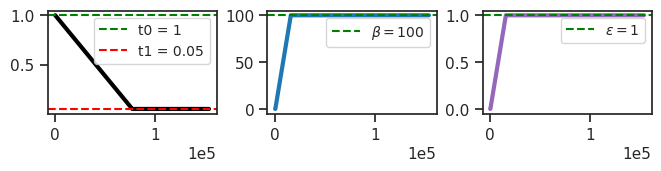

In [4]:
mod = IPVAE(ConfigPoisVAE(**cfg_vae))
self = tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [5]:
# tr.model.layer.update_n_exp(0.3)
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:1', dtype=torch.int32)

In [6]:
print(tr.model.layer)

PoissonLayer(input_dim=256, latent_dim=512, temperature=1, beta_inner=1, eps=1)

In [7]:
tr.model.layer.log_bias.shape, tr.model.layer.log_lr.exp()

(torch.Size([1, 512]), tensor([1.], device='cuda:1', grad_fn=<ExpBackward0>))

In [8]:
cm = f"obst-{tr.model.cfg.obs_time}"
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 300, avg loss: 242.802577: 100%|████| 300/300 [2:36:47<00:00, 31.36s/it]


## take it from here

In [9]:
print(tr.model.layer.n_exp)

tensor([ 3,  4,  5,  6,  6,  7,  8,  9, 10, 11, 12, 12, 13, 14, 14, 14],
       device='cuda:1', dtype=torch.int32)

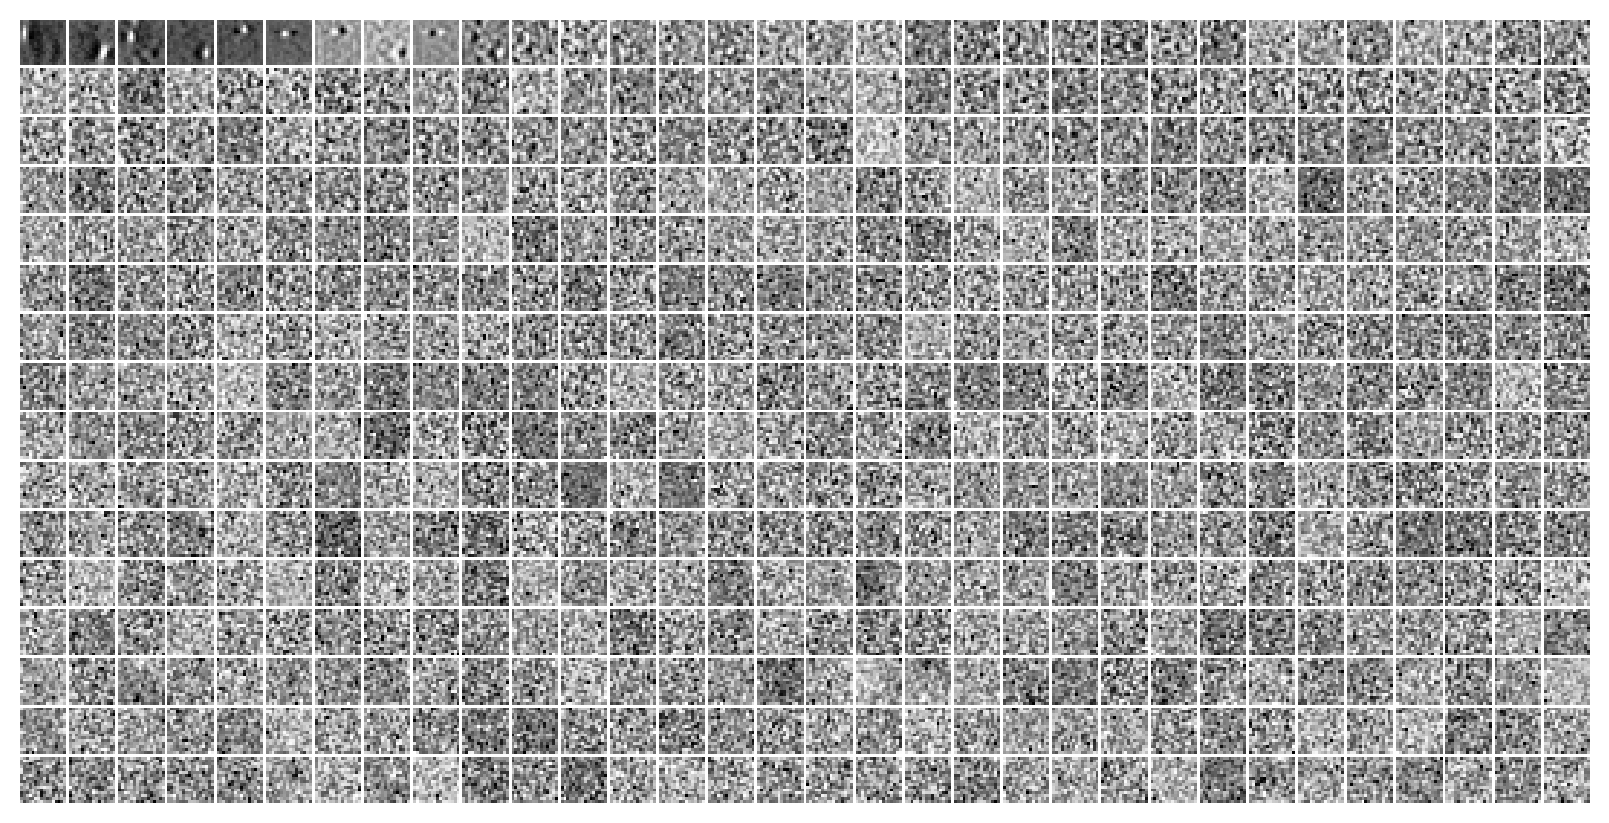

In [10]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

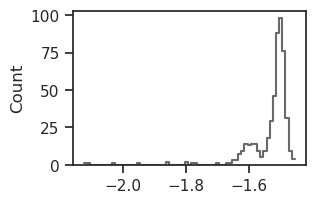

In [11]:
histplot(u0, color='dimgrey');

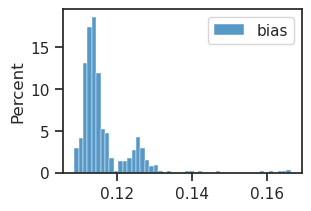

In [12]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent', ax=ax)
ax.legend()
plt.show()

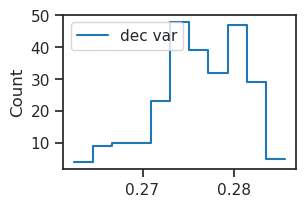

In [13]:
log_scale = tonp(tr.model.layer.log_scale.squeeze())
histplot(np.exp(log_scale) ** 2, label='dec var')
plt.legend()
plt.show()

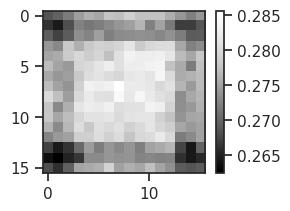

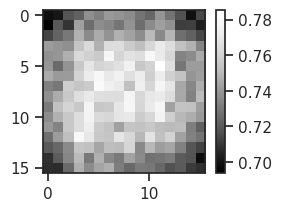

In [14]:
var = np.exp(log_scale) ** 2
var = var.reshape(16, 16)

var_data = tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze()

fig, ax =  create_figure()
imshow(var, cmap='Greys_r')
plt.colorbar()
plt.show()

fig, ax =  create_figure()
imshow(var_data, cmap='Greys_r')
plt.colorbar()
plt.show()

100%|███████████████████████████████████| 2/2 [00:41<00:00, 20.84s/it]


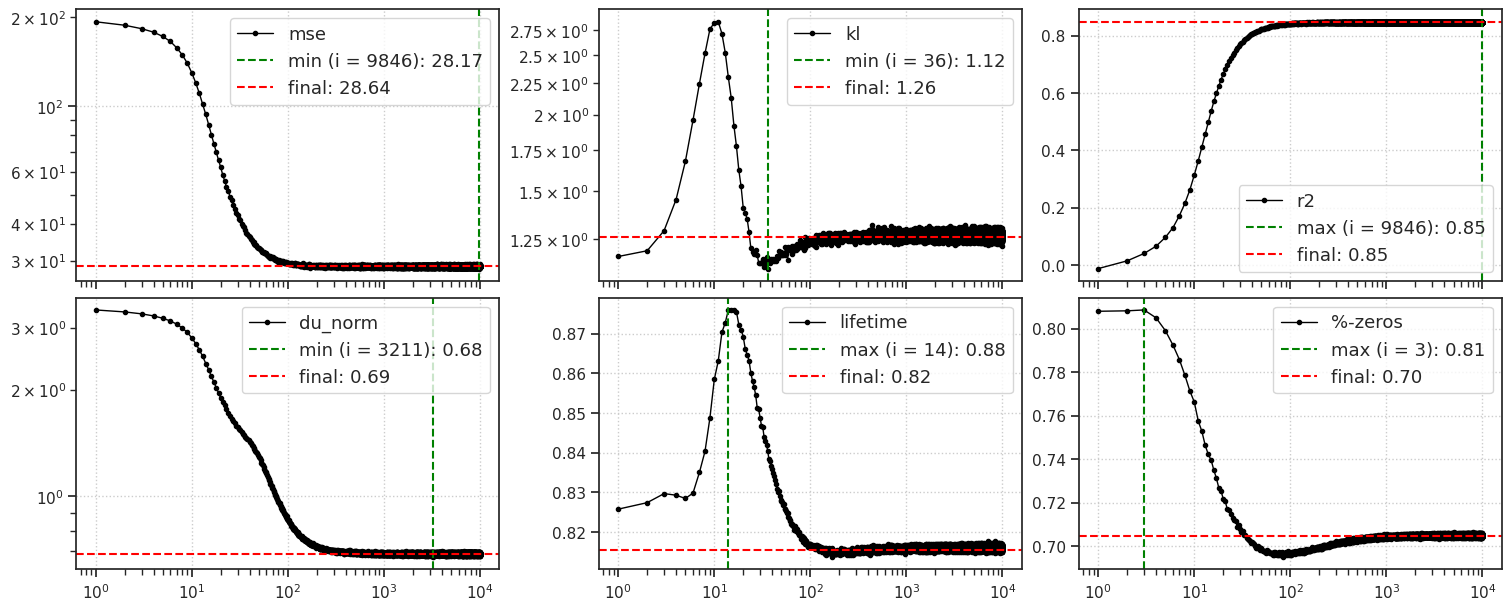

CPU times: user 50.2 s, sys: 2.73 s, total: 53 s
Wall time: 53 s


In [15]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

100%|███████████████████████████████████| 2/2 [00:41<00:00, 20.82s/it]


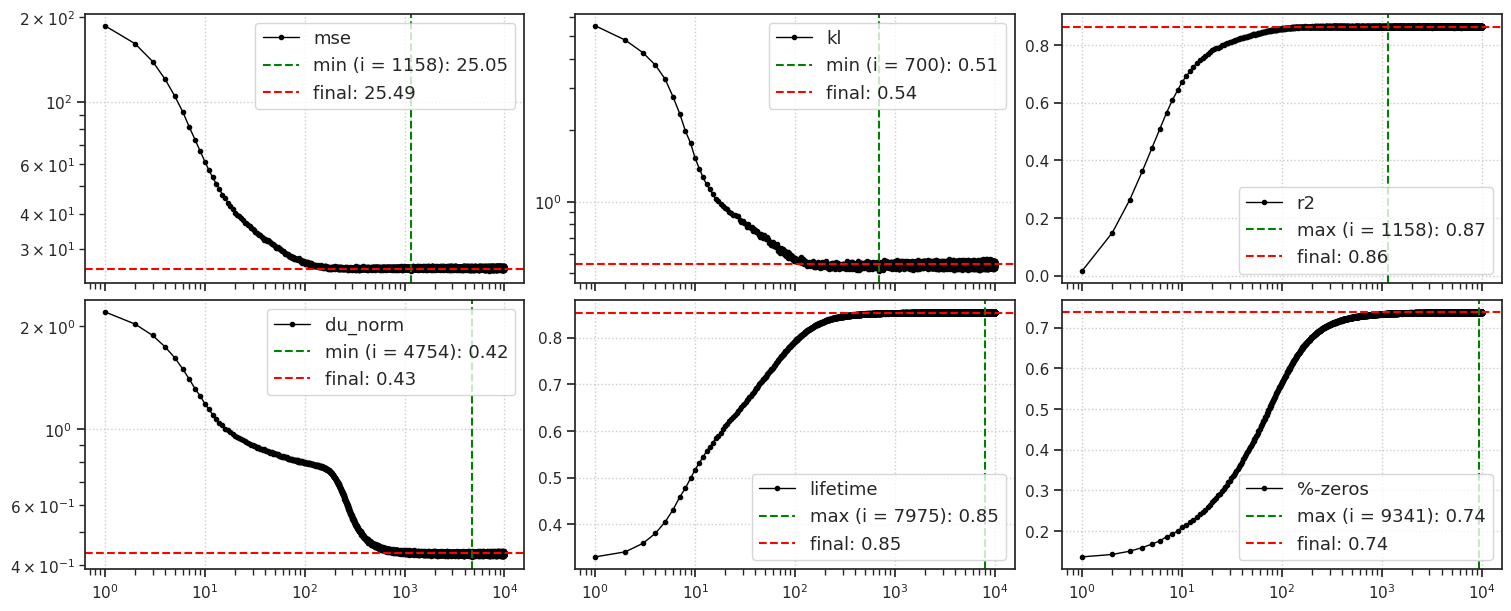

CPU times: user 50 s, sys: 2.79 s, total: 52.8 s
Wall time: 52.8 s


In [15]:
## Was: clamp_u = 8.0

## output

In [16]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

In [18]:
final_spks = tonp(output['samples'][:, -1].ravel()).astype(int)
life, _, portions = sparse_score(final_spks.reshape(-1, 1), cutoff=0.01)

print(life)
print(portions)

[0.81722499]

{
    '0': 70.5,
    '1': 5.4,
    '2': 4.6,
    '3': 3.8,
    '4': 3.3,
    '5': 2.7,
    '6': 2.2,
    '7': 1.7,
    '8': 1.4,
    '9': 1.1,
    '10': 0.8,
    '11+': 2.4
}

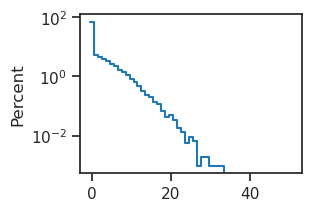

In [19]:
fig, ax = create_figure()

histplot(final_spks, stat='percent', bins=np.linspace(0, 51, 52) - 0.5)
ax.set(yscale='log');

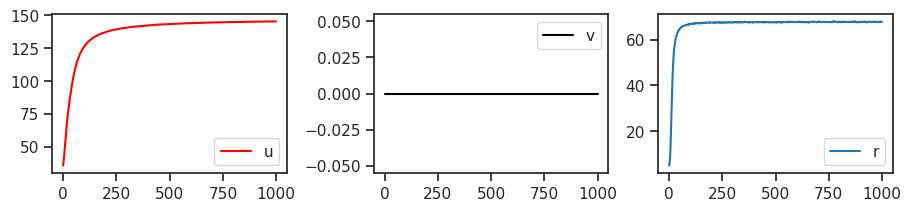

In [20]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

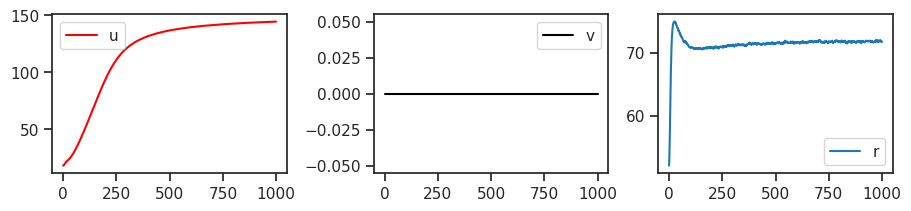

In [17]:
## Was: clamp_u = 8.0

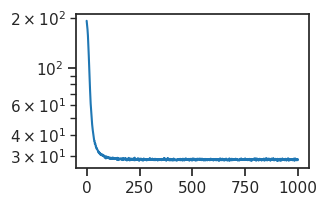

tensor([28.3199, 28.3296, 28.1301, 28.4794, 28.4474], device='cuda:1')

In [21]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)
mse = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
plot(mse.mean(0))
plt.yscale('log')
plt.show()

mse.mean(0)[-5:]

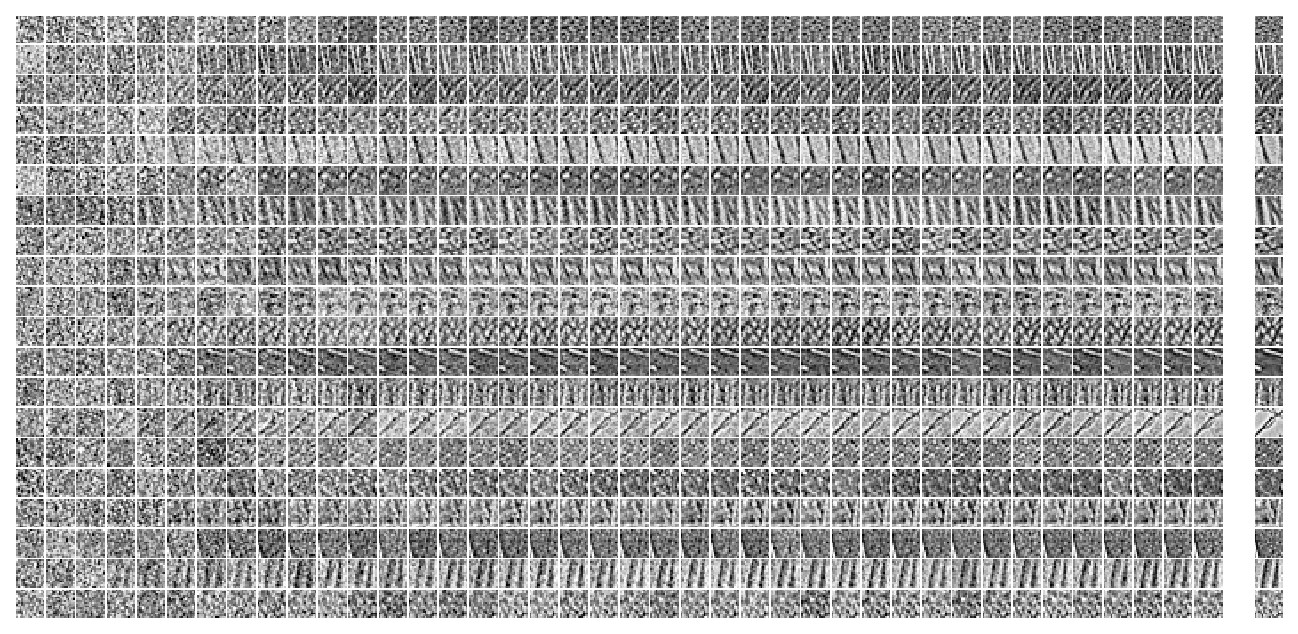

In [22]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

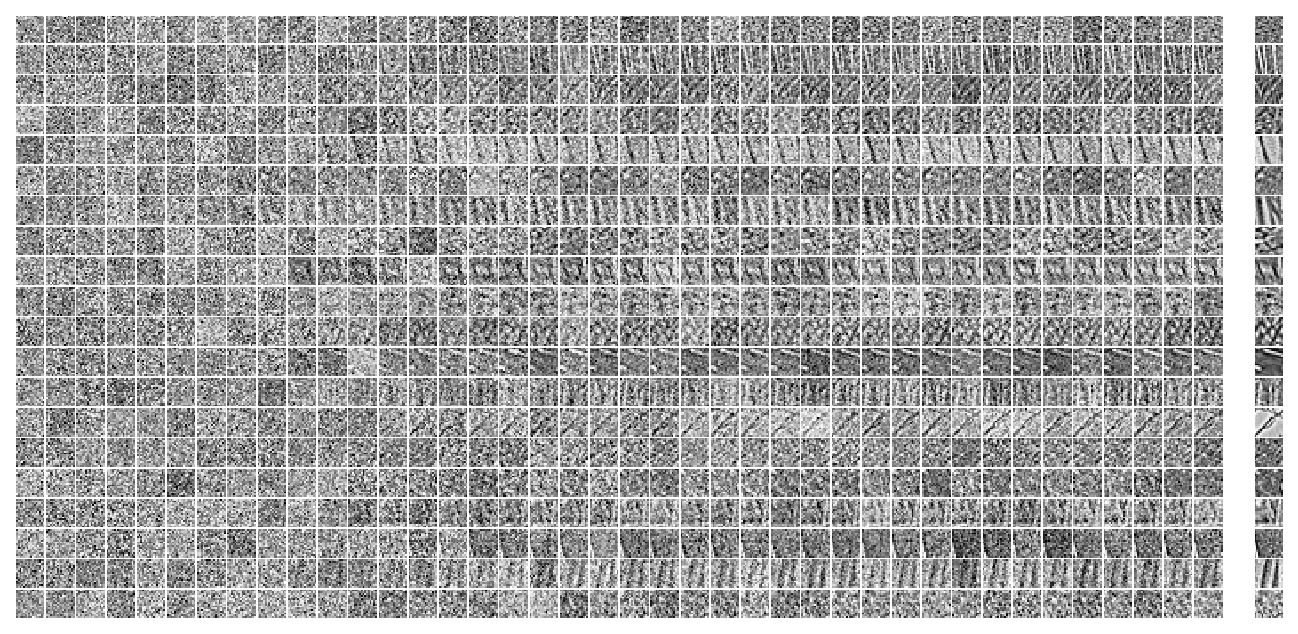

In [23]:
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)